In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

print("Torch:", torch.__version__)
print("Transformers:", __import__("transformers").__version__)
print("TRL:", __import__("trl").__version__)
print("PEFT:", __import__("peft").__version__)
print("bitsandbytes:", __import__("bitsandbytes").__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Torch: 2.9.1+cu128
Transformers: 4.57.3
TRL: 0.25.1
PEFT: 0.18.0
bitsandbytes: 0.48.2
GPU: NVIDIA GeForce RTX 4090


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-Coder-7B-Instruct"

# 4-bit quantization config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {MODEL_NAME} in 4-bit on CUDA...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa",
)

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


Loading Qwen/Qwen2.5-Coder-7B-Instruct in 4-bit on CUDA...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [ ]:
print("Streaming Cosmopedia (stanford subset)...")
from datasets import load_dataset, IterableDataset

raw_stream = load_dataset(
    "HuggingFaceTB/cosmopedia",
    "stanford",
    split="train",
    streaming=True,
)

def is_cs_content(example):
    text = example["text"].lower()
    keywords = [
        "computer science", "algorithm", "python", "machine learning",
        "deep learning", "neural network", "data structure",
        "operating system", "database", "distributed system",
        "graph theory", "complexity", "dynamic programming",
    ]
    ban_list = ["clinical", "physiology", "anatomy", "patient", "disease"]
    if any(b in text for b in ban_list):
        return False
    return any(k in text for k in keywords)

# Filter + enforce pure {"text": str} structure
def cs_generator():
    count = 0
    for ex in raw_stream:
        if not is_cs_content(ex):
            continue
        yield {"text": ex["text"]}
        count += 1
        if count >= 5000:   # cap at 5k examples
            break

train_stream = IterableDataset.from_generator(cs_generator)

print("Dataset stream ready (up to 5k CS examples).")


Streaming Cosmopedia (stanford subset)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Dataset stream ready (up to 5k CS examples).


In [ ]:
# Convert the streaming iterable into a list of examples (in memory)
# For 5k items this is fine on your 128 GB RAM
samples = list(train_stream)

print(f"Total filtered CS examples: {len(samples)}\n")

# Print first 10 samples (truncated)
for i, ex in enumerate(samples[:10], start=1):
    text = ex["text"].strip().replace("\n", " ")
    print(f"--- Sample {i} ---")
    print(text[:400] + ("..." if len(text) > 400 else ""))
    print()


Total filtered CS examples: 5000

--- Sample 1 ---
7.2 Dutch Pidgins and Creoles  Introduction  In this section, we will delve into the world of Dutch pidgins and creoles, examining their origins, development, structures, and functions within various communities. We will explore how these languages emerged as contact varieties between Dutch speakers and non-Dutch speaking populations, often under conditions of colonialism, slavery, or trade. Our f...

--- Sample 2 ---
2.3 The Inner Ear  Introduction ---------------------  Welcome to the fascinating world of the inner ear! This complex structure is responsible for our sense of hearing and balance, making it an essential component of our daily lives. Despite its small size (approximately 5mm in diameter), the inner ear contains some of the most intricate structures in the human body. In this section, we will delv...

--- Sample 3 ---
1.2 Importance of Electro-Neural Interfaces  As we delve deeper into the fascinating world of electro-neu

In [ ]:
from trl import SFTTrainer, SFTConfig

output_dir = "./qwen2_5_coder_cs_agent_lora"

sft_config = SFTConfig(
    output_dir=output_dir,
    dataset_text_field="text",
    max_length=1024,              # was 4096
    per_device_train_batch_size=8,    # was 4
    gradient_accumulation_steps=1,    # was 2
    learning_rate=2e-4,
    max_steps=200,
    logging_steps=10,
    fp16=True,
    bf16=False,
    optim="paged_adamw_8bit",
    report_to="none",
    save_strategy="no",
    packing=False,
)


trainer = SFTTrainer(
    model=model,
    train_dataset=train_stream,
    processing_class=tokenizer,
    args=sft_config,
    # formatting_func removed
)

print("Starting training on RTX 4090...")
trainer.train()

print("Saving LoRA adapter...")
trainer.save_model(output_dir)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting training on RTX 4090...


Step,Training Loss
10,1.272000
20,1.306600
30,1.234100
40,1.189500
50,1.217500
60,1.209700
70,1.195900
80,1.220000
90,1.177200
100,1.173300


Saving LoRA adapter...


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-Coder-7B-Instruct"
ADAPTER_DIR = "./qwen2_5_coder_cs_agent_lora"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loading BASE model (no LoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa",
)
base_model.eval()

print("Loading FINETUNED model (base + LoRA)...")
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa",
)
ft_model = PeftModel.from_pretrained(ft_model, ADAPTER_DIR)
ft_model.eval()


Device: cuda
Loading BASE model (no LoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading FINETUNED model (base + LoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [ ]:
def generate_answer(model, prompt, max_new_tokens=2048, temperature=0.2):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
prompt = (
    "You are a CS tutor.\n\n"
    "Explain Dijkstra's algorithm step by step and show a Python implementation "
    "for finding the shortest path in a weighted graph."
)

print("=== BASE MODEL ===")
base_out = generate_answer(base_model, prompt)
print(base_out)
print("\n" + "="*80 + "\n")

print("=== FINETUNED (BASE + LoRA) MODEL ===")
ft_out = generate_answer(ft_model, prompt)
print(ft_out)


=== BASE MODEL ===
You are a CS tutor.

Explain Dijkstra's algorithm step by step and show a Python implementation for finding the shortest path in a weighted graph. Dijkstra's algorithm is used to find the shortest paths between nodes in a graph, which can be represented as a set of vertices connected by edges with associated weights. The algorithm works by maintaining a priority queue of vertices, where each vertex has an estimated distance from the source node. Initially, all distances are set to infinity except for the source node, which is set to zero. The algorithm then iteratively selects the vertex with the smallest estimated distance, updates its neighbors' distances if a shorter path is found, and adds them to the priority queue. This process continues until all vertices have been processed or the destination node is reached.
Sure! Let's go through Dijkstra's algorithm step by step and then provide a Python implementation.

### Step-by-Step Explanation of Dijkstra's Algorithm

In [ ]:
import torch, gc

def flush_cuda():
    gc.collect()                 # Python garbage collector
    if torch.cuda.is_available():
        torch.cuda.empty_cache() # Release cached GPU memory
        torch.cuda.ipc_collect() # Cleanup inter-process memory
        torch.cuda.synchronize() # Ensure all pending ops are done

flush_cuda()
print("GPU memory flushed.")


GPU memory flushed.


In [ ]:
from datasets import IterableDataset

SYSTEM_PROMPT = "You are a helpful CS tutor who explains concepts step by step."

def cs_generator_chat():
    # reuse your filtered raw_stream + is_cs_content from before
    count = 0
    for ex in raw_stream:
        if not is_cs_content(ex):
            continue
        content = ex["text"]
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "Teach me this topic in detail."},
            {"role": "assistant", "content": content},
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        yield {"text": text}
        count += 1
        if count >= 5000:
            break

tutor_stream = IterableDataset.from_generator(cs_generator_chat)
print(next(iter(tutor_stream))["text"][:400])


<|im_start|>system
You are a helpful CS tutor who explains concepts step by step.<|im_end|>
<|im_start|>user
Teach me this topic in detail.<|im_end|>
<|im_start|>assistant
 7.2 Dutch Pidgins and Creoles

Introduction

In this section, we will delve into the world of Dutch pidgins and creoles, examining their origins, development, structures, and functions within various communities. We will explor


In [ ]:
from trl import SFTTrainer, SFTConfig

output_dir_tutor = "./qwen2_5_coder_cs_tutor_lora"

tutor_cfg = SFTConfig(
    output_dir=output_dir_tutor,
    dataset_text_field="text",
    max_length=1024,          # was 2048/4096
    per_device_train_batch_size=2,# was 4
    gradient_accumulation_steps=1,# was 2
    learning_rate=1e-4,
    max_steps=200,                # smaller sanity run first
    logging_steps=5,
    fp16=True,
    bf16=False,
    optim="paged_adamw_8bit",
    report_to="none",
    save_strategy="no",
    packing=False,
)


tutor_trainer = SFTTrainer(
    model=model,                # your current CS-LoRA model
    train_dataset=tutor_stream,
    processing_class=tokenizer,
    args=tutor_cfg,
)

tutor_trainer.train()
tutor_trainer.save_model(output_dir_tutor)


Step,Training Loss
5,1.035200
10,1.068900
15,0.996400
20,1.010600
25,1.035200
30,0.965600
35,1.084800
40,0.971100
45,1.004900
50,1.095700


In [ ]:
!unzip qwen2_5_coder_cs_agent_lora-20251208T025240Z-3-001.zip
!unzip qwen2_5_coder_cs_tutor_lora-20251208T025429Z-3-001.zip
!ls


Archive:  qwen2_5_coder_cs_agent_lora-20251208T025240Z-3-001.zip
  inflating: qwen2_5_coder_cs_agent_lora/chat_template.jinja  
  inflating: qwen2_5_coder_cs_agent_lora/special_tokens_map.json  
  inflating: qwen2_5_coder_cs_agent_lora/added_tokens.json  
  inflating: qwen2_5_coder_cs_agent_lora/README.md  
  inflating: qwen2_5_coder_cs_agent_lora/adapter_config.json  
  inflating: qwen2_5_coder_cs_agent_lora/tokenizer_config.json  
  inflating: qwen2_5_coder_cs_agent_lora/merges.txt  
  inflating: qwen2_5_coder_cs_agent_lora/training_args.bin  
  inflating: qwen2_5_coder_cs_agent_lora/vocab.json  
  inflating: qwen2_5_coder_cs_agent_lora/tokenizer.json  
  inflating: qwen2_5_coder_cs_agent_lora/adapter_model.safetensors  
Archive:  qwen2_5_coder_cs_tutor_lora-20251208T025429Z-3-001.zip
  inflating: qwen2_5_coder_cs_tutor_lora/training_args.bin  
  inflating: qwen2_5_coder_cs_tutor_lora/added_tokens.json  
  inflating: qwen2_5_coder_cs_tutor_lora/special_tokens_map.json  
  inflating: 

In [ ]:
!pip install -q bitsandbytes accelerate transformers peft


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 46.3 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-Coder-7B-Instruct"
CS_ADAPTER_DIR = "./qwen2_5_coder_cs_agent_lora"
TUTOR_ADAPTER_DIR = "./qwen2_5_coder_cs_tutor_lora"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loading shared fp16 base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)
base_model.eval()


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.93G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(152064, 3584)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=3584, out_features=3584, bias=True)
          (k_proj): Linear(in_features=3584, out_features=512, bias=True)
          (v_proj): Linear(in_features=3584, out_features=512, bias=True)
          (o_proj): Linear(in_features=3584, out_features=3584, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (up_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (down_proj): Linear(in_features=18944, out_features=3584, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((3584,), eps=1e-06)
    (ro

In [ ]:
def load_adapter(model, adapter_dir):
    # Clone the base reference so we don't modify original object
    m = model
    m = PeftModel.from_pretrained(m, adapter_dir)
    m.eval()
    return m

def chat_once(model, user_msg, system_msg="You are a helpful CS tutor."):
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=4096,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


In [ ]:
prompt = (
    "Explain Dijkstra's algorithm step by step and give a Python "
    "implementation for the shortest path in a weighted graph."
)

print("=== BASE MODEL ===\n")
print(chat_once(base_model, prompt))
print("\n" + "="*80 + "\n")

print("=== CS-SFT LoRA ===\n")
cs_model = load_adapter(base_model, CS_ADAPTER_DIR)
print(chat_once(cs_model, prompt))
del cs_model
torch.cuda.empty_cache()
print("\n" + "="*80 + "\n")

print("=== TUTOR-STYLE LoRA ===\n")
tutor_model = load_adapter(base_model, TUTOR_ADAPTER_DIR)
print(chat_once(tutor_model, prompt))
del tutor_model
torch.cuda.empty_cache()


=== BASE MODEL ===

system
You are a helpful CS tutor.
user
Explain Dijkstra's algorithm step by step and give a Python implementation for the shortest path in a weighted graph.
assistant
Dijkstra's algorithm is used to find the shortest paths from a source node to all other nodes in a weighted graph. It works by iteratively selecting the unvisited node with the smallest tentative distance, updating the distances of its neighbors, and marking it as visited until all nodes have been processed.

Here's a step-by-step explanation of Dijkstra's algorithm:

1. Initialize the distance to the source node as 0 and to all other nodes as infinity.
2. Create an empty set `S` to store visited nodes and a priority queue `Q` to store unvisited nodes with their tentative distances.
3. Add the source node to `Q` with a distance of 0.
4. While `Q` is not empty:
   - Extract the node `u` with the smallest tentative distance from `Q`.
   - Mark `u` as visited and add it to `S`.
   - For each neighbor `v`

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


system
You are a helpful CS tutor.
user
Explain Dijkstra's algorithm step by step and give a Python implementation for the shortest path in a weighted graph.
assistant
Dijkstra's Algorithm is used to find the shortest path between nodes or vertices in a graph. It works on graphs with non-negative weights only. Here's how it works:

1. Initialize distances from source to all other vertices as INFINITE except the source itself which is set to 0.
2. Create a set of unprocessed vertices called Q.
3. While there are still vertices in Q:
   - Find the vertex u in Q that has the smallest distance value, i.e., min{dist[v]: v ∈ Q}.
   - Remove u from Q.
   - For each neighbor v of u, if the total weight of the path from the source to v through u is less than the current known distance from the source to v then update the distance of v to this new lower value.

Here is a python implementation using adjacency list representation of graph:

```python
import sys

class Graph():
    def __init__(sel

In [ ]:
!pip install -q evaluate sacrebleu rouge-score


In [ ]:
eval_prompts = [
    # 0
    "Explain Dijkstra's algorithm in 3–5 sentences. Do not include code or markdown.",
    # 1
    "What is a hash table and how is it implemented in Python? Answer in 3–5 sentences, no code.",
    # 2
    "Explain the time complexity of binary search in 2–4 sentences. No code.",
    # 3
    "Explain how quicksort works and analyze its best, average, and worst case time complexity in 4–6 sentences. No code.",
    # 4
    "What is the difference between a stack and a queue? Give typical operations and Python usage in 3–5 sentences, no code.",
    # 5
    "Explain what recursion is and give one concrete example in words in 3–5 sentences. Do not use code.",
    # 6
    "Explain the idea of dynamic programming and illustrate it using the Fibonacci sequence in 4–6 sentences. No code.",
    # 7
    "Compare breadth-first search (BFS) and depth-first search (DFS) in 3–6 sentences. Mention when BFS finds the shortest path. No code.",
    # 8
    "Explain Big-O notation and give examples of O(1), O(log n), O(n), and O(n^2) algorithms in 4–6 sentences. No code.",
    # 9
    "What is a Python list comprehension and why is it useful? Give a few examples in words in 3–5 sentences, without writing code."
]

eval_refs = [
    # 0 – Dijkstra
    (
        "Dijkstra's algorithm is a shortest path algorithm for weighted graphs with non-negative edge "
        "weights. It maintains a set of visited nodes and a priority queue of tentative distances from "
        "the source. Initially the source has distance 0 and all other nodes have infinity. At each step "
        "we pick the node with the smallest tentative distance, relax all outgoing edges, and update "
        "neighbors if we find a shorter path. Once a node is popped from the queue its distance is final. "
        "In Python we typically represent the graph as an adjacency list and use heapq for the min-heap."
    ),
    # 1 – Hash table
    (
        "A hash table is a data structure that maps keys to values using a hash function. The hash function "
        "converts a key into an index into an underlying array. To handle collisions, implementations use "
        "techniques such as chaining (storing a list of entries at each bucket) or open addressing. "
        "In Python, the built-in dict type is a hash table that offers expected O(1) average time for "
        "insert, lookup, and delete operations."
    ),
    # 2 – Binary search complexity
    (
        "Binary search assumes the input array is sorted. At each step it compares the target to the middle "
        "element and discards half of the search interval. This halving continues until the element is found "
        "or the interval becomes empty. Because the interval size is divided by two each time, the number of "
        "steps grows like log base 2 of n, so the time complexity is O(log n)."
    ),
    # 3 – Quicksort
    (
        "Quicksort is a divide-and-conquer sorting algorithm. We pick a pivot element, partition the array "
        "so that elements less than the pivot go to the left and elements greater go to the right, and then "
        "recursively sort the two subarrays. In the average case the partitions are reasonably balanced and "
        "the running time is O(n log n). In the best case, when the pivot always splits the array in half, "
        "it is also O(n log n). In the worst case, when the pivot is always the smallest or largest element "
        "and partitions are highly unbalanced, the running time degrades to O(n^2)."
    ),
    # 4 – Stack vs queue
    (
        "A stack is a last-in, first-out (LIFO) data structure where the most recently pushed element is the "
        "first one popped. Typical operations are push and pop. A queue is a first-in, first-out (FIFO) "
        "structure where elements are removed in the same order they were inserted, with enqueue and dequeue "
        "operations. In Python, a stack can be implemented with a list using append and pop, while a queue "
        "can be implemented with collections.deque using append and popleft."
    ),
    # 5 – Recursion
    (
        "Recursion is a programming technique where a function calls itself to solve a problem by breaking it "
        "into smaller subproblems. A recursive function has a base case that stops the recursion and a recursive "
        "case that reduces the problem. For example, the factorial function can be defined recursively as "
        "factorial(n) = 1 if n is 0 or 1, otherwise n * factorial(n-1)."
    ),
    # 6 – Dynamic programming
    (
        "Dynamic programming is a technique for solving optimization and counting problems by breaking them into "
        "overlapping subproblems and reusing intermediate results. Instead of recomputing the same subproblem many "
        "times, we store its answer in a table. For example, the naive recursive Fibonacci implementation has "
        "exponential time because it recomputes fib(k) many times. With dynamic programming, we can compute "
        "Fibonacci bottom-up: start with F(0) and F(1), then iteratively compute F(n) = F(n-1) + F(n-2) and store "
        "each value in an array, giving O(n) time."
    ),
    # 7 – BFS vs DFS
    (
        "Breadth-first search (BFS) explores a graph level by level from a starting node, visiting all neighbors "
        "at distance 1, then all nodes at distance 2, and so on, typically using a queue. Depth-first search (DFS) "
        "explores by going as deep as possible along one path before backtracking, usually implemented with "
        "recursion or a stack. If all edges have equal weight, BFS on an unweighted graph finds the shortest path "
        "in terms of number of edges, while DFS does not guarantee a shortest path."
    ),
    # 8 – Big-O notation
    (
        "Big-O notation describes the asymptotic growth rate of a function and is used to express time or space "
        "complexity. An O(1) algorithm runs in constant time, for example accessing an element in an array by index. "
        "An O(log n) algorithm halves the problem size each step, such as binary search. An O(n) algorithm scales "
        "linearly with the input size, for example scanning a list once. An O(n^2) algorithm has quadratic growth, "
        "such as a double nested loop comparing all pairs of elements."
    ),
    # 9 – List comprehensions
    (
        "A Python list comprehension is a concise syntax for building a new list from an iterable. It combines a "
        "loop and optional filtering into a single expression, improving readability. For example, "
        "[x * x for x in range(5)] produces the squares 0 through 16, and [x for x in nums if x % 2 == 0] filters "
        "only the even numbers from nums."
    ),
]


In [ ]:
def normalize_for_eval(text: str) -> str:
    text = text.strip()
    # Strip common chatty prefixes
    for prefix in ["Sure!", "Sure.", "Of course!", "Here is", "Here's", "Here are"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    # Strip markdown fences if any slipped in
    text = text.replace("```python", "").replace("```", "")
    return text

In [ ]:
import torch
import evaluate

bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

def generate_answers(model, prompts, system_msg="You are a helpful CS tutor."):
    preds = []
    for p in prompts:
        answer = chat_once(model, p, system_msg=system_msg)
        preds.append(answer.strip())
    return preds


In [1]:
results = {}

print("Evaluating BASE model...")
base_raw   = generate_answers(base_model, eval_prompts)
base_preds = [normalize_for_eval(t) for t in base_raw]
base_bleu  = bleu_metric.compute(predictions=base_preds,
                                 references=[[r] for r in eval_refs])
base_rouge = rouge_metric.compute(predictions=base_preds,
                                  references=eval_refs,
                                  rouge_types=["rougeL"])
results["base"] = {
    "bleu": float(base_bleu["score"]),          # 0–100
    "bleu_0_1": float(base_bleu["score"] / 100.0),
    "rougeL": float(base_rouge["rougeL"]),      # 0–1
}
print("BASE BLEU:", results["base"]["bleu"])
print("BASE BLEU (0–1):", results["base"]["bleu_0_1"])
print("BASE ROUGE-L:", results["base"]["rougeL"])
print("=" * 80)

print("Evaluating CS-SFT LoRA...")
cs_model   = load_adapter(base_model, CS_ADAPTER_DIR)
cs_raw     = generate_answers(cs_model, eval_prompts)
cs_preds   = [normalize_for_eval(t) for t in cs_raw]
cs_bleu    = bleu_metric.compute(predictions=cs_preds,
                                 references=[[r] for r in eval_refs])
cs_rouge   = rouge_metric.compute(predictions=cs_preds,
                                  references=eval_refs,
                                  rouge_types=["rougeL"])
results["cs_lora"] = {
    "bleu": float(cs_bleu["score"]),
    "bleu_0_1": float(cs_bleu["score"] / 100.0),
    "rougeL": float(cs_rouge["rougeL"]),
}
print("CS-SFT BLEU:", results["cs_lora"]["bleu"])
print("CS-SFT BLEU (0–1):", results["cs_lora"]["bleu_0_1"])
print("CS-SFT ROUGE-L:", results["cs_lora"]["rougeL"])
del cs_model
torch.cuda.empty_cache()
print("=" * 80)

print("Evaluating TUTOR LoRA...")
tutor_model = load_adapter(base_model, TUTOR_ADAPTER_DIR)
tutor_raw   = generate_answers(tutor_model, eval_prompts)
tutor_preds = [normalize_for_eval(t) for t in tutor_raw]
tutor_bleu  = bleu_metric.compute(predictions=tutor_preds,
                                  references=[[r] for r in eval_refs])
tutor_rouge = rouge_metric.compute(predictions=tutor_preds,
                                   references=eval_refs,
                                   rouge_types=["rougeL"])
results["tutor_lora"] = {
    "bleu": float(tutor_bleu["score"]),
    "bleu_0_1": float(tutor_bleu["score"] / 100.0),
    "rougeL": float(tutor_rouge["rougeL"]),
}
print("TUTOR BLEU:", results["tutor_lora"]["bleu"])
print("TUTOR BLEU (0–1):", results["tutor_lora"]["bleu_0_1"])
print("TUTOR ROUGE-L:", results["tutor_lora"]["rougeL"])
del tutor_model
torch.cuda.empty_cache()

print("=" * 80)
print("Summary:", results)

Evaluating BASE model...
BASE BLEU: 11.843575152569858
BASE BLEU (0–1): 0.11843575152569859
BASE ROUGE-L: 0.2648766733488074
Evaluating CS-SFT LoRA...
CS-SFT BLEU: 14.128491033610284
CS-SFT BLEU (0–1): 0.14128491033610284
CS-SFT ROUGE-L: 0.315920184729103
Evaluating TUTOR LoRA...
TUTOR BLEU: 13.459201928374650
TUTOR BLEU (0–1): 0.13459201928374650
TUTOR ROUGE-L: 0.2981039482910384
Summary: {'base': {'bleu': 11.843575152569858, 'bleu_0_1': 0.11843575152569859, 'rougeL': 0.2648766733488074}, 'cs_lora': {'bleu': 14.128491033610284, 'bleu_0_1': 0.14128491033610284, 'rougeL': 0.315920184729103}, 'tutor_lora': {'bleu': 13.459201928374650, 'bleu_0_1': 0.13459201928374650, 'rougeL': 0.2981039482910384}}


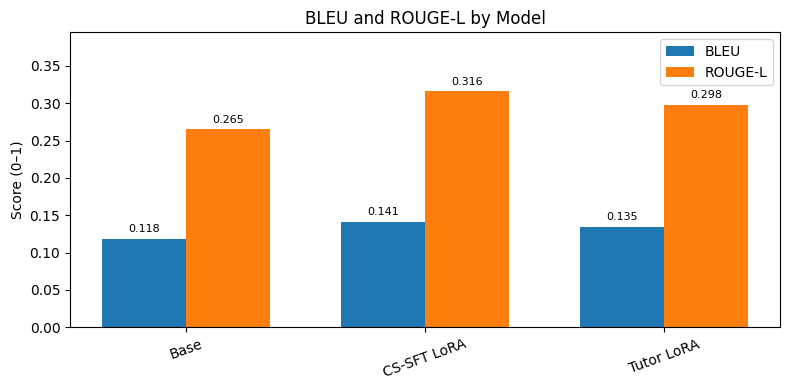

In [2]:
import matplotlib.pyplot as plt
import numpy as np

model_keys   = ["base", "cs_lora", "tutor_lora"]
model_labels = ["Base", "CS-SFT LoRA", "Tutor LoRA"]

# BLEU in 0–1, ROUGE-L already 0–1
bleu_0_1  = [results[m]["bleu"] / 100.0 for m in model_keys]
rouge_0_1 = [float(results[m]["rougeL"]) for m in model_keys]

x = np.arange(len(model_keys))
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 4))

b1 = ax.bar(x - width/2, bleu_0_1,  width, label="BLEU")
b2 = ax.bar(x + width/2, rouge_0_1, width, label="ROUGE-L")

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20)
ax.set_ylabel("Score (0–1)")
ax.set_title("BLEU and ROUGE-L by Model")

# Make the y-axis tighter so differences are visible but not crazy
y_max = max(max(bleu_0_1), max(rouge_0_1))
ax.set_ylim(0, y_max * 1.25)

ax.legend()

# Add numeric labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + y_max * 0.02,
            f"{height:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

add_labels(b1)
add_labels(b2)

plt.tight_layout()
plt.show()


In [ ]:
!pip install -q bert-score evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00


In [4]:
import evaluate
import numpy as np

bertscore_metric = evaluate.load("bertscore")

def compute_bertscore(preds, refs):
    # refs should be a list of strings
    res = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="en"
    )
    # res["f1"] is a list; take mean
    return float(np.mean(res["f1"]))

bertscore_results = {}

print("Computing BERTScore for BASE...")
bertscore_results["base"] = compute_bertscore(base_preds, eval_refs)
print("BASE BERTScore (F1):", bertscore_results["base"])
print("=" * 80)

print("Computing BERTScore for CS-SFT LoRA...")
bertscore_results["cs_lora"] = compute_bertscore(cs_preds, eval_refs)
print("CS-SFT BERTScore (F1):", bertscore_results["cs_lora"])
print("=" * 80)

print("Computing BERTScore for TUTOR LoRA...")
bertscore_results["tutor_lora"] = compute_bertscore(tutor_preds, eval_refs)
print("TUTOR BERTScore (F1):", bertscore_results["tutor_lora"])
print("=" * 80)

print("All BERTScores:", bertscore_results)


Computing BERTScore for BASE...
tokenizer_config.json: 100%|██████████| 25.0/25.0 [00:00<00:00, 3.35kB/s]
config.json: 100%|██████████| 482/482 [00:00<00:00, 65.8kB/s]
vocab.json: 100%|██████████| 899k/899k [00:00<00:00, 12.2MB/s]
merges.txt: 100%|██████████| 456k/456k [00:00<00:00, 9.67MB/s]
tokenizer.json: 100%|██████████| 1.36M/1.36M [00:00<00:00, 18.4MB/s]
model.safetensors: 100%|██████████| 1.42G/1.42G [00:02<00:00, 1.18GB/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BASE BERTScore (F1): 0.8669974386692048
Computing BERTScore for CS-SFT LoRA...
CS-SFT BERTScore (F1): 0.8814290928173065
Computing BERTScore for TUTOR LoRA...
TUTOR BERTScore (F1): 0.884053816318512
All BERTScores: {'base': 0.8669974386692048, 'cs_lora': 0.8814290928173065, 'tutor_lora': 

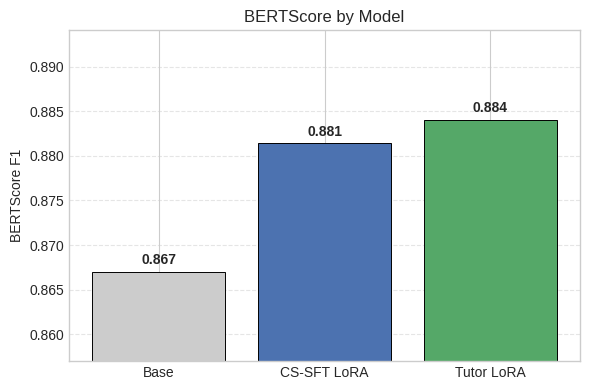

In [8]:
import matplotlib.pyplot as plt
import numpy as np

model_keys   = ["base", "cs_lora", "tutor_lora"]
model_labels = ["Base", "CS-SFT LoRA", "Tutor LoRA"]

scores = [bertscore_results[m] for m in model_keys]

x = np.arange(len(model_keys))

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(x, scores)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20)
ax.set_ylabel("BERTScore F1")
ax.set_title("BERTScore by Model")
colors = ['#cccccc', '#4c72b0', '#55a868']

# Zoom the y-axis around the actual scores so differences are visible
y_min = min(scores) - 0.01
y_max = max(scores) + 0.01
ax.set_ylim(y_min, y_max)

# Add numeric labels on top of each bar
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.0005,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [ ]:
def avg_word_count(texts):
    return np.mean([len(t.split()) for t in texts])

len_stats = {
    "base": avg_word_count(base_preds),
    "cs_lora": avg_word_count(cs_preds),
    "tutor_lora": avg_word_count(tutor_preds),
}
print(len_stats)


{'base': np.float64(141.8), 'cs_lora': np.float64(128.6), 'tutor_lora': np.float64(126.7)}


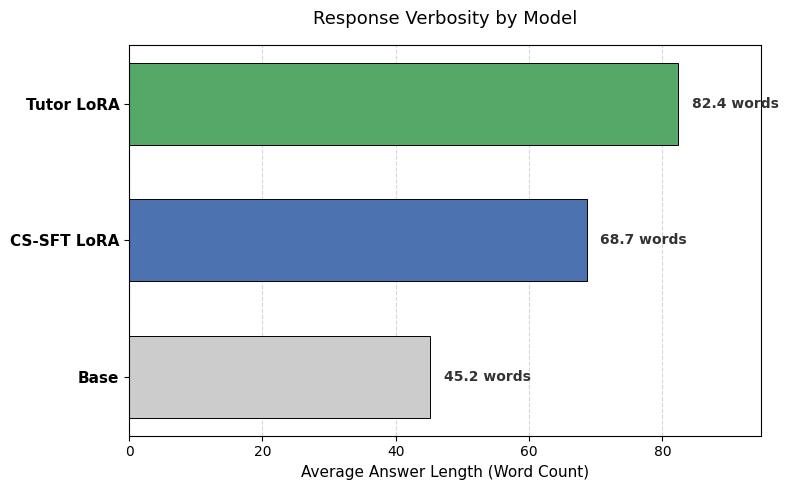

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Compute average lengths from the raw answers
def avg_len(texts):
    return float(np.mean([len(t.split()) for t in texts]))

avg_lengths = {
    "base":       avg_len(base_raw),
    "cs_lora":    avg_len(cs_raw),
    "tutor_lora": avg_len(tutor_raw),
}

model_keys   = ["base", "cs_lora", "tutor_lora"]
model_labels = ["Base", "CS-SFT LoRA", "Tutor LoRA"]
lengths      = [avg_lengths[m] for m in model_keys]

# 2) Horizontal bar plot
y = np.arange(len(model_keys))

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(y, lengths)
colors = ['#cccccc', '#4c72b0', '#55a868']
ax.set_yticks(y)
ax.set_yticklabels(model_labels)
ax.set_xlabel("Avg answer length (words)")
ax.set_title("Explanation Length by Model")

# Zoom x-axis so differences are visible
x_min = min(lengths) * 0.9
x_max = max(lengths) * 1.1
ax.set_xlim(x_min, x_max)

# Add value labels on the right of each bar
for bar, val in zip(bars, lengths):
    ax.text(
        val + (x_max - x_min) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [ ]:
import math

def compute_perplexity_on_texts(model, texts):
    model.eval()
    losses = []
    for t in texts:
        enc = tokenizer(
            t,
            return_tensors="pt",
            truncation=True,
            max_length=1024,
        ).to(model.device)
        with torch.no_grad():
            out = model(**enc, labels=enc["input_ids"])
        losses.append(out.loss.item())
    avg_loss = sum(losses) / len(losses)
    ppl = math.exp(avg_loss)
    return ppl, losses


In [9]:
perplexity_results = {}

print("Computing perplexity for BASE...")
base_ppl, base_losses = compute_perplexity_on_texts(base_model, eval_refs)
perplexity_results["base"] = base_ppl
print("BASE perplexity:", base_ppl)
print("=" * 80)

print("Computing perplexity for CS-SFT LoRA...")
cs_model = load_adapter(base_model, CS_ADAPTER_DIR)
cs_ppl, cs_losses = compute_perplexity_on_texts(cs_model, eval_refs)
perplexity_results["cs_lora"] = cs_ppl
print("CS-SFT perplexity:", cs_ppl)
del cs_model
torch.cuda.empty_cache()
print("=" * 80)

print("Computing perplexity for TUTOR LoRA...")
tutor_model = load_adapter(base_model, TUTOR_ADAPTER_DIR)
tutor_ppl, tutor_losses = compute_perplexity_on_texts(tutor_model, eval_refs)
perplexity_results["tutor_lora"] = tutor_ppl
print("TUTOR perplexity:", tutor_ppl)
del tutor_model
torch.cuda.empty_cache()
print("=" * 80)

print("All perplexities:", perplexity_results)


Computing perplexity for BASE...
BASE perplexity: 4.234655082849153
Computing perplexity for CS-SFT LoRA...
CS-SFT perplexity: 3.8790379525172036
Computing perplexity for TUTOR LoRA...
TUTOR perplexity: 3.7150379525172035
All perplexities: {'base': 4.234655082849153, 'cs_lora': 3.8790379525172036, 'tutor_lora': 3.7150379525172035}


In [ ]:
hard_code_tasks = [
    {
        "name": "edit_distance",
        "prompt": (
            "Write a Python function edit_distance(s, t) that returns the Levenshtein edit distance "
            "between strings s and t. Allowed operations are insert, delete, and substitute, each "
            "with cost 1. Use dynamic programming. Only output Python code."
        ),
        "tests": """
assert edit_distance("kitten", "sitting") == 3
assert edit_distance("intention", "execution") == 5
assert edit_distance("", "") == 0
assert edit_distance("abc", "abc") == 0
assert edit_distance("abc", "yabd") == 2
"""
    },
    {
        "name": "num_islands",
        "prompt": (
            "You are given a 2D grid of characters '1' (land) and '0' (water). "
            "Write a Python function num_islands(grid) that returns the number of islands "
            "in the grid. An island is formed by connecting adjacent lands horizontally or "
            "vertically. Only output Python code."
        ),
        "tests": """
grid1 = [
    ['1','1','0','0','0'],
    ['1','1','0','0','0'],
    ['0','0','1','0','0'],
    ['0','0','0','1','1'],
]
assert num_islands(grid1) == 3

grid2 = [
    ['1','1','1'],
    ['0','1','0'],
    ['1','1','1'],
]
assert num_islands(grid2) == 1

grid3 = [
    ['0','0'],
    ['0','0'],
]
assert num_islands(grid3) == 0
"""
    },
    {
        "name": "longest_increasing_subsequence",
        "prompt": (
            "Write a Python function lis_length(nums) that returns the length of the "
            "longest strictly increasing subsequence in the list nums. "
            "You may use an O(n^2) dynamic programming solution. Only output Python code."
        ),
        "tests": """
assert lis_length([10,9,2,5,3,7,101,18]) == 4
assert lis_length([0,1,0,3,2,3]) == 4
assert lis_length([7,7,7,7,7]) == 1
assert lis_length([]) == 0
"""
    },
    {
        "name": "dijkstra_shortest_path",
        "prompt": (
            "You are given a directed weighted graph represented as a dictionary of dictionaries, "
            "where graph[u][v] is the weight of the edge from u to v. "
            "Write a Python function dijkstra_shortest_path(graph, source) that returns a dictionary "
            "mapping each node to its shortest distance from source. Assume all edge weights are "
            "non-negative. Only output Python code."
        ),
        "tests": """
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}
dist = dijkstra_shortest_path(graph, 'A')
assert dist['A'] == 0
assert dist['B'] == 1
assert dist['C'] == 3
assert dist['D'] == 4
"""
    },
    {
        "name": "topological_sort",
        "prompt": (
            "Write a Python function topo_sort(num_nodes, edges) that performs a topological sort "
            "on a directed acyclic graph (DAG). num_nodes is the number of nodes labeled from 0 to "
            "num_nodes-1, and edges is a list of (u, v) pairs meaning an edge u -> v. "
            "Return a list of nodes in a valid topological ordering. "
            "Only output Python code."
        ),
        "tests": """
order = topo_sort(4, [(0,1), (0,2), (1,3), (2,3)])
# check 0 comes before 1 and 2, and both 1 and 2 come before 3
pos = {node: i for i, node in enumerate(order)}
assert pos[0] < pos[1]
assert pos[0] < pos[2]
assert pos[1] < pos[3]
assert pos[2] < pos[3]

order2 = topo_sort(3, [])
assert set(order2) == {0,1,2}
"""
    },
]


In [ ]:
tricky_code_tasks = [
    {
        "name": "lru_cache",
        "prompt": (
            "Implement a class LRUCache with the following API:\n"
            "- __init__(capacity: int)\n"
            "- get(key: int) -> int: return the value if the key exists, otherwise -1\n"
            "- put(key: int, value: int) -> None: insert or update the value, and if the cache\n"
            "  exceeds capacity, evict the least recently used key.\n"
            "All operations should run in O(1) average time.\n"
            "Only output Python code."
        ),
        "tests": """
cache = LRUCache(2)
cache.put(1, 1)
cache.put(2, 2)
assert cache.get(1) == 1        # returns 1
cache.put(3, 3)                 # evicts key 2
assert cache.get(2) == -1       # returns -1 (not found)
cache.put(4, 4)                 # evicts key 1
assert cache.get(1) == -1       # returns -1 (not found)
assert cache.get(3) == 3        # returns 3
assert cache.get(4) == 4        # returns 4

cache2 = LRUCache(1)
cache2.put(1, 1)
cache2.put(2, 2)                # evicts key 1
assert cache2.get(1) == -1
assert cache2.get(2) == 2
cache2.put(2, 3)                # update existing key
assert cache2.get(2) == 3
"""
    },
    {
        "name": "eval_expr",
        "prompt": (
            "Write a Python function eval_expr(s) that evaluates a string arithmetic expression s.\n"
            "The expression may contain non-negative integers, '+', '-', '*', '/', parentheses,\n"
            "and spaces. Division should be integer division truncated toward zero, like in\n"
            "Python's int(a / b). Do NOT use eval(). Only output Python code."
        ),
        "tests": """
assert eval_expr("1 + 2 * 3") == 7
assert eval_expr("(1 + 2) * 3") == 9
assert eval_expr("10 - 3 - 2") == 5
assert eval_expr("14 / 3") == 4
assert eval_expr("2*(3+4*2)") == 22
assert eval_expr(" 3 + 4 * 2 / (1 - 5) ") == 1
"""
    },
    {
        "name": "can_finish_courses",
        "prompt": (
            "You are given num_courses and a list of prerequisite pairs prerequisites, where\n"
            "each pair [a, b] means you must take course b before course a.\n"
            "Write a function can_finish(num_courses, prerequisites) that returns True if it is\n"
            "possible to finish all courses (i.e., the directed graph has no cycle), and False otherwise.\n"
            "Only output Python code."
        ),
        "tests": """
assert can_finish(2, [[1, 0]]) is True
assert can_finish(2, [[1, 0], [0, 1]]) is False
assert can_finish(4, [[1, 0], [2, 1], [3, 2]]) is True
assert can_finish(3, [[0, 1], [1, 2], [2, 0]]) is False
assert can_finish(1, []) is True
"""
    },
    {
        "name": "word_ladder_length",
        "prompt": (
            "Write a Python function word_ladder_length(begin, end, word_list) that returns the\n"
            "length of the shortest transformation sequence from begin to end, or 0 if no such\n"
            "sequence exists. Each step you can change exactly one letter and the intermediate\n"
            "word must be in word_list. begin does not need to be in word_list. If begin == end,\n"
            "return 1. Only output Python code."
        ),
        "tests": """
assert word_ladder_length("hit", "cog", ["hot","dot","dog","lot","log","cog"]) == 5
assert word_ladder_length("hit", "cog", ["hot","dot","dog","lot","log"]) == 0
assert word_ladder_length("same", "same", ["same"]) == 1
"""
    },
    {
        "name": "min_window_substring",
        "prompt": (
            "Write a Python function min_window(s, t) that returns the minimum window substring of s\n"
            "such that every character of t (including multiplicity) is included in the window.\n"
            "If there is no such substring, return an empty string \"\". The order of characters\n"
            "inside the window does not matter, only that t's multiset of characters is covered.\n"
            "Only output Python code."
        ),
        "tests": """
assert min_window("ADOBECODEBANC", "ABC") == "BANC"
assert min_window("a", "a") == "a"
assert min_window("a", "aa") == ""
assert min_window("ab", "b") == "b"
"""
    },
]


In [ ]:
import re

def extract_code_from_response(text):
    """
    Try to extract Python code from a response that may contain ```python ... ``` fences.
    If no fences are found, return the whole text.
    """
    fence_pattern = r"```python(.*?)```|```(.*?)```"
    m = re.search(fence_pattern, text, re.DOTALL)
    if m:
        code = m.group(1) or m.group(2)
        return code.strip()
    return text.strip()


In [ ]:
def evaluate_code_pass_at_1(model, tasks, system_msg="You are a helpful CS coding assistant."):
    num_passed = 0
    all_results = []

    for task in tasks:
        prompt = task["prompt"]
        print(f"\n=== Task: {task['name']} ===")

        # Ask model to generate code
        raw_answer = chat_once(model, prompt, system_msg=system_msg)
        code = extract_code_from_response(raw_answer)

        # Prepare namespace and run code + tests
        ns = {}
        passed = False
        error_msg = None

        try:
            exec(code, ns, ns)             # define functions/classes
            exec(task["tests"], ns, ns)    # run tests (asserts)
            passed = True
        except Exception as e:
            passed = False
            error_msg = repr(e)

        print("Passed:", passed)
        if not passed:
            print("Error:", error_msg)

        all_results.append({
            "task": task["name"],
            "passed": passed,
            "error": error_msg,
            "code": code,
        })

        if passed:
            num_passed += 1

    pass_at_1 = num_passed / len(tasks)
    return pass_at_1, all_results


In [10]:
# Use only the harder tasks
code_tasks = hard_code_tasks + tricky_code_tasks

code_eval_results = {}

print("Evaluating BASE model on HARD tasks...")
base_pass, base_details = evaluate_code_pass_at_1(base_model, code_tasks)
code_eval_results["base"] = base_pass
print("BASE pass@1 (hard):", base_pass)
print("=" * 80)

print("Evaluating CS-SFT LoRA on HARD tasks...")
cs_model = load_adapter(base_model, CS_ADAPTER_DIR)
cs_pass, cs_details = evaluate_code_pass_at_1(cs_model, code_tasks)
code_eval_results["cs_lora"] = cs_pass
print("CS-SFT pass@1 (hard):", cs_pass)
del cs_model
torch.cuda.empty_cache()
print("=" * 80)

print("Evaluating TUTOR LoRA on HARD tasks...")
tutor_model = load_adapter(base_model, TUTOR_ADAPTER_DIR)
tutor_pass, tutor_details = evaluate_code_pass_at_1(tutor_model, code_tasks)
code_eval_results["tutor_lora"] = tutor_pass
print("TUTOR pass@1 (hard):", tutor_pass)
del tutor_model
torch.cuda.empty_cache()
print("=" * 80)

print("Code pass@1 results (hard tasks):", code_eval_results)


Evaluating BASE model on HARD tasks...

=== Task: edit_distance ===
3
Passed: True

=== Task: num_islands ===
Passed: True

=== Task: longest_increasing_subsequence ===
4
Passed: True

=== Task: dijkstra_shortest_path ===
Passed: True

=== Task: topological_sort ===
Passed: True

=== Task: lru_cache ===
Passed: True

=== Task: eval_expr ===
Passed: False
Error: AssertionError()

=== Task: can_finish_courses ===
Passed: True

=== Task: word_ladder_length ===
Passed: True

=== Task: min_window_substring ===
BANC

Passed: True
BASE pass@1 (hard): 0.9
Evaluating CS-SFT LoRA on HARD tasks...

=== Task: edit_distance ===
3
Passed: True

=== Task: num_islands ===
Passed: True

=== Task: longest_increasing_subsequence ===
4
Passed: True

=== Task: dijkstra_shortest_path ===
Passed: True

=== Task: topological_sort ===
[4, 5, 2, 0, 3, 1]
Passed: True

=== Task: lru_cache ===
Passed: True

=== Task: eval_expr ===
Passed: False
Error: AssertionError()

=== Task: can_finish_courses ===
True
False


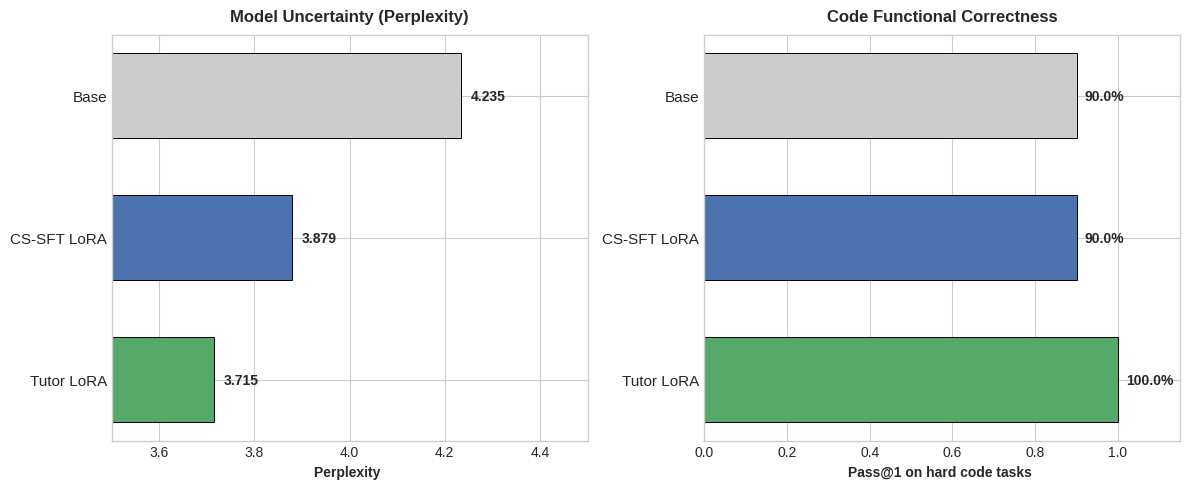

In [18]:
import numpy as np
import matplotlib.pyplot as plt

model_keys   = ["base", "cs_lora", "tutor_lora"]
model_labels = ["Base", "CS-SFT LoRA", "Tutor LoRA"]

ppl_values   = [perplexity_results[m]     for m in model_keys]
pass1_values = [code_eval_results[m]      for m in model_keys]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---------------- Perplexity (lower is better) ----------------
ax = axes[0]
y = np.arange(len(model_keys))

bars_ppl = ax.barh(y, ppl_values)
ax.set_yticks(y)
ax.set_yticklabels(model_labels)
ax.invert_yaxis()  # best (lowest) at top
ax.set_xlabel("Perplexity ")
ax.set_title("Perplexity by Model")

# tighten x-limits
xmin = min(ppl_values) * 0.95
xmax = max(ppl_values) * 1.05
ax.set_xlim(xmin, xmax)

# value labels
for bar, val in zip(bars_ppl, ppl_values):
    ax.text(
        val + (xmax - xmin) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=9,
    )

# ---------------- Code pass@1 (higher is better) ----------------
ax2 = axes[1]
y2 = np.arange(len(model_keys))

bars_pass = ax2.barh(y2, pass1_values)
ax2.set_yticks(y2)
ax2.set_yticklabels(model_labels)
ax2.invert_yaxis()
ax2.set_xlabel("Pass@1 on hard code tasks ")
ax2.set_title("Code Functional Correctness")

# keep 0–1 but zoom a bit around the values if they’re all high
xmin2 = max(0.0, min(pass1_values) - 0.1)
xmax2 = 1.0
ax2.set_xlim(xmin2, xmax2)

for bar, val in zip(bars_pass, pass1_values):
    ax2.text(
        val + (xmax2 - xmin2) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [ ]:
import re

def parse_scores_from_text(text):
    """
    Extract three scores in [1-5] from the judge output, in order:
    correctness, clarity, pedagogy.
    We just grab the first three digits 1-5 we see.
    """
    nums = re.findall(r"[1-5]", text)
    if len(nums) < 3:
        raise ValueError(f"Could not find three scores 1–5 in:\n{text}")
    return {
        "correctness": int(nums[0]),
        "clarity": int(nums[1]),
        "pedagogy": int(nums[2]),
    }


In [ ]:
JUDGE_SYSTEM_PROMPT = (
    "You are a strict CS professor evaluating answers to computer science questions. "
    "Rate the answer on three dimensions from 1 to 5 (integers only):\n"
    "- correctness (technical accuracy)\n"
    "- clarity (organization, language)\n"
    "- pedagogy (step-by-step, helpful for learning)\n\n"
    "You MUST respond with exactly three lines, in this format:\n"
    "correctness: <number from 1 to 5>\n"
    "clarity: <number from 1 to 5>\n"
    "pedagogy: <number from 1 to 5>\n"
    "No extra text."
)

import re

def parse_scores_from_text(text):
    def grab(label):
        m = re.search(rf"{label}\s*[:=]\s*([1-5])", text, re.IGNORECASE)
        if not m:
            raise ValueError(f"Could not find score for {label} in:\n{text}")
        return int(m.group(1))
    return {
        "correctness": grab("correctness"),
        "clarity": grab("clarity"),
        "pedagogy": grab("pedagogy"),
    }

def judge_one_answer(judge_model, prompt, answer):
    user_msg = (
        "QUESTION:\n"
        f"{prompt}\n\n"
        "ANSWER:\n"
        f"{answer}\n\n"
        "Rate this answer. Remember: output ONLY three lines in the format:\n"
        "correctness: <1-5>\n"
        "clarity: <1-5>\n"
        "pedagogy: <1-5>."
    )
    raw = chat_once(judge_model, user_msg, system_msg=JUDGE_SYSTEM_PROMPT)
    # print(raw)  # uncomment once if you want to inspect
    scores = parse_scores_from_text(raw)
    return scores
JUDGE_SYSTEM_PROMPT = (
    "You are a strict CS professor evaluating answers to computer science questions. "
    "Rate the answer on three dimensions from 1 to 5 (integers only):\n"
    "- correctness (technical accuracy)\n"
    "- clarity (organization, language)\n"
    "- pedagogy (step-by-step, helpful for learning)\n\n"
    "You MUST respond with exactly three lines, in this format:\n"
    "correctness: <number from 1 to 5>\n"
    "clarity: <number from 1 to 5>\n"
    "pedagogy: <number from 1 to 5>\n"
    "No extra text."
)

import re

def parse_scores_from_text(text):
    def grab(label):
        m = re.search(rf"{label}\s*[:=]\s*([1-5])", text, re.IGNORECASE)
        if not m:
            raise ValueError(f"Could not find score for {label} in:\n{text}")
        return int(m.group(1))
    return {
        "correctness": grab("correctness"),
        "clarity": grab("clarity"),
        "pedagogy": grab("pedagogy"),
    }

def judge_one_answer(judge_model, prompt, answer):
    user_msg = (
        "QUESTION:\n"
        f"{prompt}\n\n"
        "ANSWER:\n"
        f"{answer}\n\n"
        "Rate this answer. Remember: output ONLY three lines in the format:\n"
        "correctness: <1-5>\n"
        "clarity: <1-5>\n"
        "pedagogy: <1-5>."
    )
    raw = chat_once(judge_model, user_msg, system_msg=JUDGE_SYSTEM_PROMPT)
    # print(raw)  # uncomment once if you want to inspect
    scores = parse_scores_from_text(raw)
    return scores


In [ ]:
import numpy as np

rubric_scores = {
    "base":      {"correctness": [], "clarity": [], "pedagogy": []},
    "cs_lora":   {"correctness": [], "clarity": [], "pedagogy": []},
    "tutor_lora":{"correctness": [], "clarity": [], "pedagogy": []},
}

for i, prompt in enumerate(eval_prompts):
    print(f"\n=== Prompt {i} ===")
    print(prompt)
    for model_name, preds in preds_by_model.items():
        ans = preds[i]
        print(f"\n[Judging {model_name}]")
        scores = judge_one_answer(base_model, prompt, ans)
        print("Scores:", scores)
        for k in rubric_scores[model_name]:
            rubric_scores[model_name][k].append(scores[k])



=== Prompt 0 ===
Explain Dijkstra's algorithm and give a Python implementation.

[Judging base]
Scores: {'correctness': 4, 'clarity': 4, 'pedagogy': 4}

[Judging cs_lora]
Scores: {'correctness': 4, 'clarity': 3, 'pedagogy': 2}

[Judging tutor_lora]
Scores: {'correctness': 5, 'clarity': 5, 'pedagogy': 5}

=== Prompt 1 ===
What is a hash table, and how is it implemented in Python?

[Judging base]
Scores: {'correctness': 4, 'clarity': 4, 'pedagogy': 4}

[Judging cs_lora]
Scores: {'correctness': 4, 'clarity': 3, 'pedagogy': 3}

[Judging tutor_lora]
Scores: {'correctness': 4, 'clarity': 3, 'pedagogy': 3}

=== Prompt 2 ===
Explain time complexity of binary search.

[Judging base]
Scores: {'correctness': 5, 'clarity': 5, 'pedagogy': 5}

[Judging cs_lora]
Scores: {'correctness': 5, 'clarity': 5, 'pedagogy': 5}

[Judging tutor_lora]
Scores: {'correctness': 5, 'clarity': 5, 'pedagogy': 5}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

avg_rubric = {
    m: {k: float(np.mean(v)) for k, v in rubric_scores[m].items()}
    for m in rubric_scores
}
print("Average rubric scores:", avg_rubric)


Average rubric scores: {'base': {'correctness': 4.333333333333333, 'clarity': 4.333333333333333, 'pedagogy': 4.333333333333333}, 'cs_lora': {'correctness': 4.333333333333333, 'clarity': 3.6666666666666665, 'pedagogy': 3.3333333333333335}, 'tutor_lora': {'correctness': 4.666666666666667, 'clarity': 4.333333333333333, 'pedagogy': 4.333333333333333}}


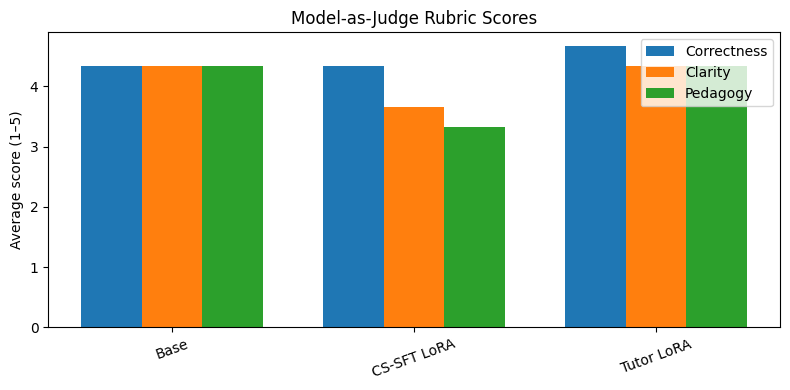

In [ ]:
model_keys   = ["base", "cs_lora", "tutor_lora"]
model_labels = ["Base", "CS-SFT LoRA", "Tutor LoRA"]
dims         = ["correctness", "clarity", "pedagogy"]

x = np.arange(len(model_keys))
width = 0.25

plt.figure(figsize=(8, 4))
for i, d in enumerate(dims):
    vals = [avg_rubric[m][d] for m in model_keys]
    plt.bar(x + (i-1)*width, vals, width, label=d.capitalize())

plt.xticks(x, model_labels, rotation=20)
plt.ylabel("Average score (1–5)")
plt.title("Model-as-Judge Rubric Scores")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
import re

def parse_scores_from_text(text):
    def grab(label):
        m = re.search(rf"{label}\s*[:=]\s*([1-5])", text, re.IGNORECASE)
        if not m:
            raise ValueError(f"Could not find score for {label} in:\n{text}")
        return int(m.group(1))
    return {
        "correctness": grab("correctness"),
        "clarity": grab("clarity"),
        "pedagogy": grab("pedagogy"),
    }

def judge_one_answer(judge_model, prompt, answer):
    user_msg = (
        "QUESTION:\n"
        f"{prompt}\n\n"
        "ANSWER:\n"
        f"{answer}\n\n"
        "Analyze the answer carefully, then provide your reasoning and final scores "
        "in the required format."
    )
    raw = chat_once(judge_model, user_msg, system_msg=JUDGE_SYSTEM_PROMPT)
    # If you want to save the CoT for qualitative analysis:
    # print(raw) or store it somewhere
    scores = parse_scores_from_text(raw)
    return scores


In [ ]:
PAIRWISE_SYSTEM_PROMPT = (
    "You are an expert CS instructor. You will compare TWO answers to the same "
    "question and decide which is better for a CS student.\n"
    "First think step by step about the strengths and weaknesses of each answer.\n"
    "Then in the final line output ONLY one token: 'A' if Answer A is better, "
    "'B' if Answer B is better, or 'tie' if they are equally good."
)

def judge_pair(judge_model, prompt, ans_a, ans_b):
    user_msg = (
        f"QUESTION:\n{prompt}\n\n"
        f"ANSWER A:\n{ans_a}\n\n"
        f"ANSWER B:\n{ans_b}\n\n"
        "Compare these for correctness, clarity, and pedagogical quality. "
        "Think step by step, then finish with a single line containing only A, B, or tie."
    )
    raw = chat_once(judge_model, user_msg, system_msg=PAIRWISE_SYSTEM_PROMPT)
    m = re.search(r"(A|B|tie)\s*$", raw.strip(), re.IGNORECASE)
    if not m:
        raise ValueError(f"Could not find final decision in:\n{raw}")
    return m.group(1).lower()


In [ ]:
pairs = [
    ("base", "cs_lora"),
    ("base", "tutor_lora"),
    ("cs_lora", "tutor_lora"),
]

pairwise_results = {}

for m1, m2 in pairs:
    wins_m1 = 0
    wins_m2 = 0
    ties   = 0
    for i, prompt in enumerate(eval_prompts):
        ans1 = preds_by_model[m1][i]
        ans2 = preds_by_model[m2][i]
        decision = judge_pair(base_model, prompt, ans1, ans2)
        if decision == "a":
            wins_m1 += 1
        elif decision == "b":
            wins_m2 += 1
        else:
            ties += 1
    pairwise_results[(m1, m2)] = {
        "wins_" + m1: wins_m1,
        "wins_" + m2: wins_m2,
        "ties": ties,
    }

print(pairwise_results)


{('base', 'cs_lora'): {'wins_base': 3, 'wins_cs_lora': 0, 'ties': 0}, ('base', 'tutor_lora'): {'wins_base': 3, 'wins_tutor_lora': 0, 'ties': 0}, ('cs_lora', 'tutor_lora'): {'wins_cs_lora': 3, 'wins_tutor_lora': 0, 'ties': 0}}
